In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path,"AB_NYC_2019.csv"))

df.head()

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
df.shape

(48895, 16)

In [8]:
missing = df.isnull().sum()
missing[missing>0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [9]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

<Axes: xlabel='room_type', ylabel='count'>

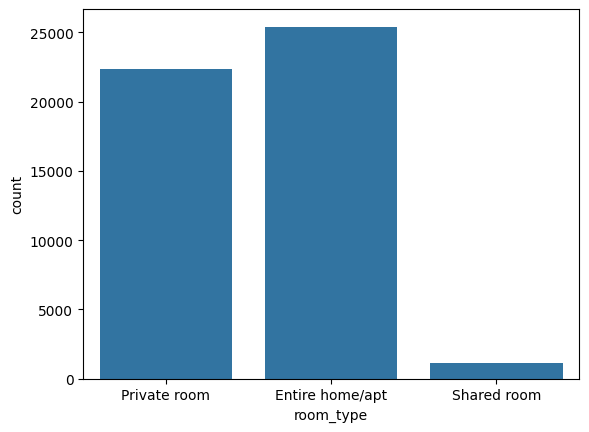

In [10]:
df['room_type'].value_counts()

sns.countplot(x = df['room_type'])

The classes are imbalanced ->  shared room is a small minority

**Univariate Analysis - Numeric Features**

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

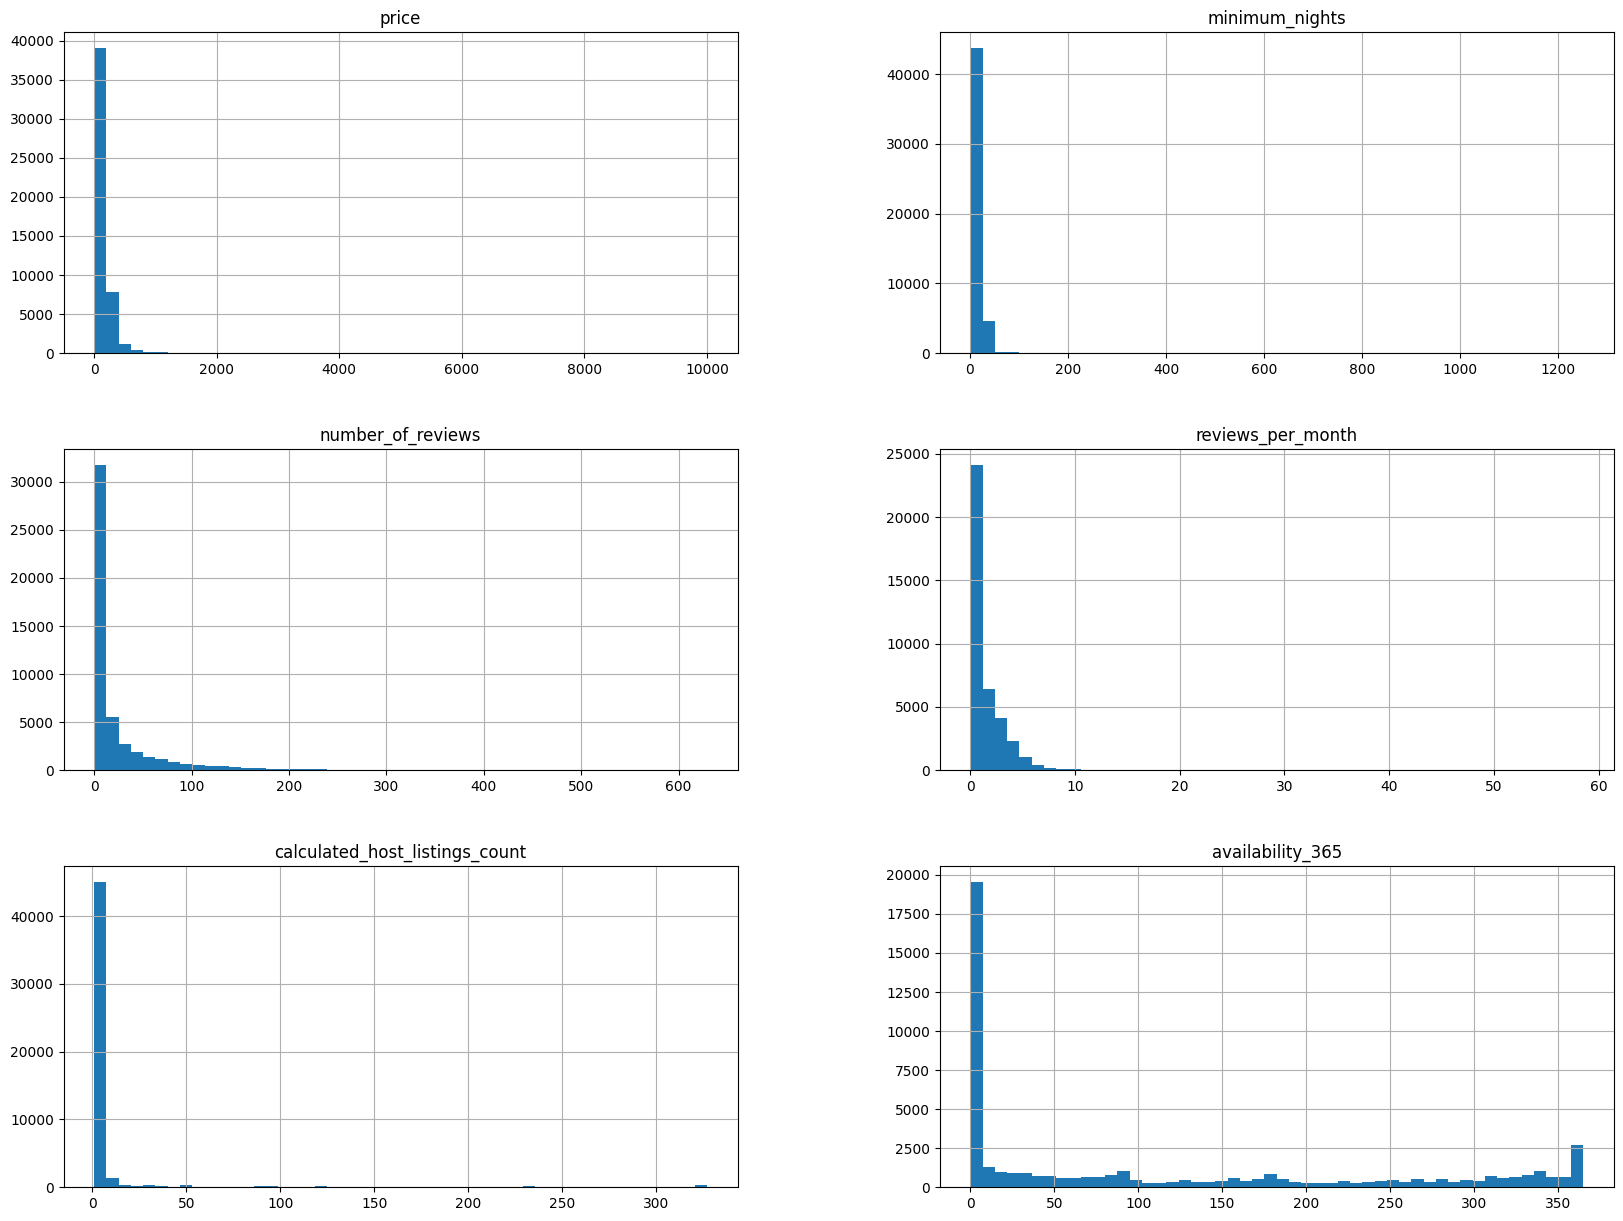

In [11]:
numeric_cols = ['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']

df[numeric_cols].hist(bins=50, figsize=(20,15))


**Univariate Analysis - Categorical features**

<Axes: xlabel='neighbourhood_group', ylabel='count'>

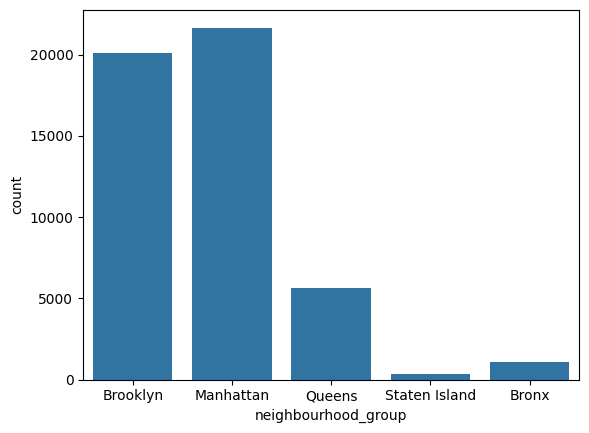

In [12]:
sns.countplot(x=df['neighbourhood_group'])

Bivariate Analysis -> feature vs target

<Axes: xlabel='room_type', ylabel='price'>

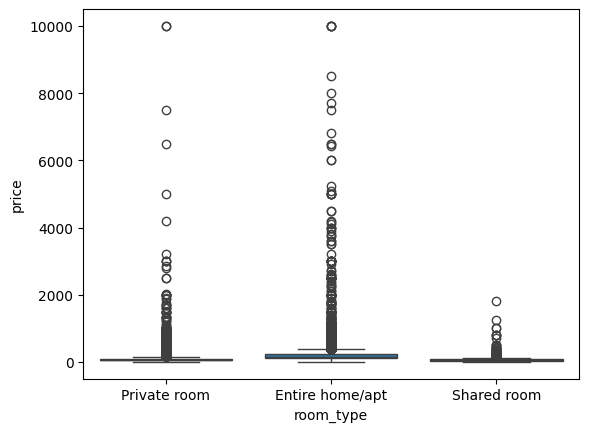

In [13]:
sns.boxplot(x = df['room_type'], y = df['price'])

**Correlation heatmap**

<Axes: >

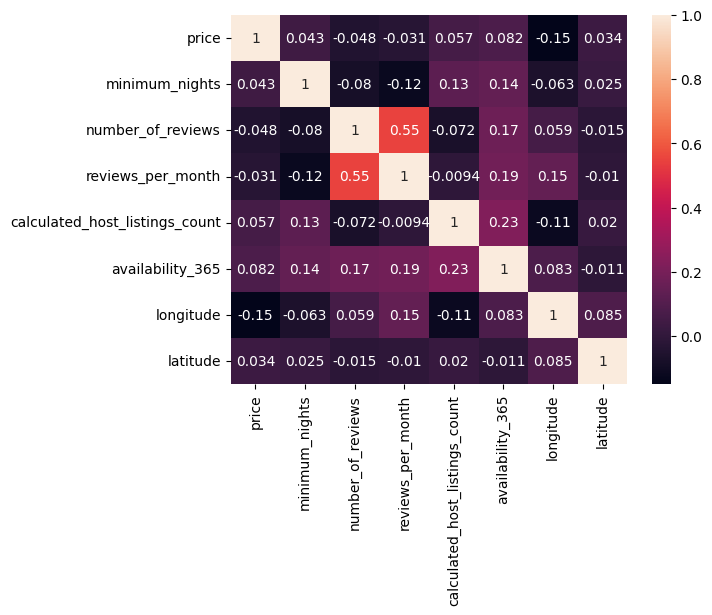

In [14]:
corr = df[numeric_cols +  ['longitude', 'latitude']].corr()
sns.heatmap(corr, annot=True)

**Geograpic distribution**

<Axes: xlabel='longitude', ylabel='latitude'>

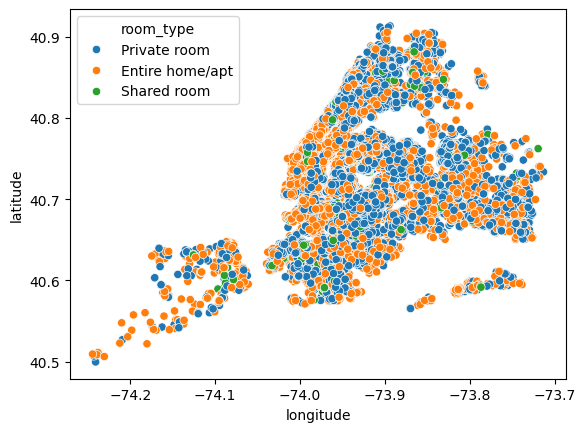

In [15]:
sns.scatterplot(x = 'longitude', y = 'latitude', data = df ,hue = 'room_type')

**Data Cleaning and Feature engineering**

In [16]:
#1. Drop columns that dont help us.
df_clean = df.drop(columns=['id','name','host_name','last_review','host_id'])

#2. no reveiews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

#3. cap extreme outliers instead of deleting rows
price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)


In [17]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify = y)
#stratify ye ensure karta hai ki jab bhi hum split ya sample kare , har group (class) ka original proportion maintain rahe

**Preprocessing - columntransformer + pipeline**

In [19]:
df_clean

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [20]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer

In [21]:
numerical_cols = ['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365','longitude','latitude']
categorical_cols = ['neighbourhood_group','neighbourhood']

#1st pipeline -> numeric cols
numeric_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#2nd pipeline -> categorical cols
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

**SMOTE(synthetic minority oversampling)**

for class imbalance
*   high chance of overfitting
*   Data leakage
*   instead of this we use class_weight



In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [23]:
# class_weight = "Balanced" tells the model to pay more attention to the minority class or rare class (shared room)
#  but the problem  is gradientbosting doesn't support class weight so we left it as it is.

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced",random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    pipe = Pipeline(steps = [
        ("preprocessor",preprocessor),
        ("classifier", model)
    ])


    # Accuracy alone can be misleading on imbalanced classes, so we use macro f1 both : plain acuracy and macro f1
    # (which treats every class equally)

    accuracy = cross_val_score(pipe, X_train, y_train, cv=3, scoring="accuracy")
    macrof1 = cross_val_score(pipe, X_train, y_train, cv=3, scoring="f1_macro")

    print(f"{name} -> Accuracy:{accuracy.mean():.3f}, F1: {macrof1.mean():.3f}")


Logistic Regression -> Accuracy:0.659, F1: 0.522
Decision Tree -> Accuracy:0.782, F1: 0.651
Random Forest -> Accuracy:0.849, F1: 0.711
Gradient Boosting -> Accuracy:0.850, F1: 0.705


**Hyperparameter tuning**

In [24]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("classifier", RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365',
                                                                                'longitude',
                                                                                'latitude']),
                                                                              ('cat',
                                                                               Pipe...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [25]:
print("Best Parameters: ", search.best_params_)
print("Best CV macro-F1: ", search.best_score_)

Best Parameters:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
Best CV macro-F1:  0.7318707261720084


In [26]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("F1: ", f1_score(y_test, y_pred, average="macro"))

Accuracy:  0.8561601388200297
F1:  0.7390917053490301


<Axes: >

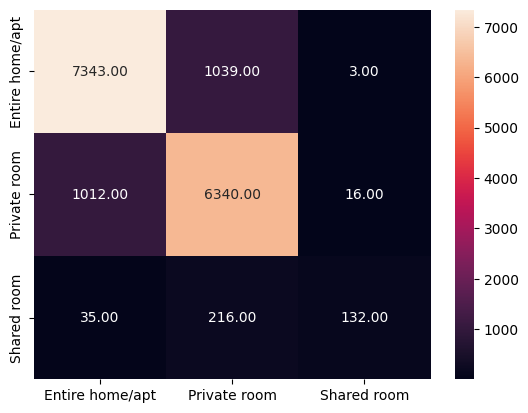

In [27]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt='.2f',xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

In [28]:
import joblib
joblib.dump(best_pipeline, 'model_pipeline.pkl')

['model_pipeline.pkl']